<a href="https://colab.research.google.com/github/ferminestrad/Simulacion/blob/main/Examen_3er_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**ESCUELA SUPERIOR DE FISICA Y MATEMATICAS**       
---
#TERCER PARCIAL
#SIMULACIÓN I
#Nombre: Fermin Estrada Buendia


#**Sistema de línea de espera con dos servidores en serie**

 Consideremos un sistema de dos servidores en serie. Las llegadas siguen un proceso de Poisson homogéneo con tasa λ y supongamos que cada llegada debe ser atendida primero por el servidor 1 y al terminar el servicio en 1, el cliente pasa al servidor 2. (Sistema de cola en *tándem o secuencial*)

  Al llegar el cliente pasará con el servidor 1, entra a servicio con el servidor 2 este se encuentra libre, o se formará en su fila. Despues de ser atendido en el servidor 2, el cliente sale del sistema. Los timepo de servicio en el servidor i tienen la distribución $G_i$, $i=1,2"$.

  **Variables**

  $t$: variable de tiempo

  $ES$: Variable de estado del sistema

$(n_1, n_2)$: si hay $n_1$ y $n_2$ clientes en el servidor 2

**Variables de conteo**

$N_A$: el número de llegadas hasta el instante t

$N_D$: el número de salidas hasta el instante t

**Variables de salida**

$A_1(n)$: la hora de llegada del cliente $n,n\geq 1$

$A_2(n)$: la hora de llegada del cliente n al servidor 2, $n\geq 1$

$D(n)$: la hora de salida del cliente n, $n \geq 1$

**Lista de eventos**

$t_A, t_1, t_2$ donde $t_A$ es la hora de la siguiente llegada, y $t_i$ es la hora a la que concluye el servicio del cliente actualmente atendido por el servidor i, $i=1, 2$. Si en un momneto dado no se encuentra un cliente con el servidor i, entonces $t_i=\infty$, $i=1,2$. La lista de eventos siempre consta de las tres variables $t_A, t_1, t_2$.

In [74]:
from random import expovariate
from math import inf as Infinity #Para cuando t_i=\infty

**PARÁMETROS**

In [77]:
lam = float(input("λ (tasa de llegadas): "))
mu1 = float(input("μ1 (tasa de servicio servidor 1): "))
mu2 = float(input("μ2 (tasa de servicio servidor 2): "))

T = float(input("Tiempo total de simulación: "))

λ (tasa de llegadas): 4
μ1 (tasa de servicio servidor 1): 5
μ2 (tasa de servicio servidor 2): 6
Tiempo total de simulación: 100


In [78]:
def TD(): #Tiempo entre llegadas.
    #Puede reemplazarse por cualquier distribución.
    return expovariate(lam)
def Y1(): #Distribución G1.
    #Tiempo de servicio del servidor 1.
    return expovariate(mu1)
def Y2(): #Distribución G2.
    #Tiempo de servicio del servidor 2.
    return expovariate(mu2)

**Inicialización**

$t=N_A=N_D=0$

$ES=(0,0)$

Generar $T_0$ y hacer $t_A = T_0$, $t_1=t_2=\infty$

Para actualizar el sistema, nos movemos en el tiempo hasta encontrar el siguiente evento. Debemos considerar diversos casos, dependiendo del mínimo de los miembros de la lista de eventos. En lo sucesivo, $Y_I$ se refiere a una variable aleatoria con distribución $G_i$, $i=1,2$


$ES=(n_1,n_2)$  $LE= t_A, t_1, t_2$

In [79]:
t = 0.0

NA = 0
ND = 0

n1 = 0
n2 = 0

# Variables de salida

A1 = {}
A2 = {}
D = {}

# Generar T0

T0 = TD()

tA = T0
t1 = Infinity
t2 = Infinity


**SIMULACIÓN (CASOS)**

**Caso 1**

$t=min(t_A, t_1, t_2)$

Restablecer $t=t_A$

Restablecer $N_A=N_A +1$

Restablecer $n_1 = n_1 + 1$

Generar $T_D$ y hacer $t_A = T_D$

Si $n_1=1$, generar $Y_1$ y hacer $t_1=t+Y_1$

Reunir los datos de salida $A_1(N_A)=t$


**Caso 2**

$t_1< t_A$, $t_1\leq t_2$

Restablecer $t=t_1$

Restablecer $n_1=n_1 - 1$,  $n_2= n_2 + 1$

Si $n_1= $ hacer $t_1= \infty$ en caso contrario, generar $Y_1$ y hacer $t_1= t + Y_1$

Si $n_2=1$, generar $Y_2$ y hacer $t_2= t +Y_2$

Reunir los datos de salida $A_2(N_A - n_1)=t$

**Caso 3**  $t_1< t_A$, $t_2< t_1$

Restablecer $t=t_2$

Restablecer $N_D=N_D+1$

Restablecer $n_2 = n_2 -1$

Si $n_2= 0$, hacer $t_2= \infty$

Si $n_2 < 0$, generar $Y_2$ y hacer $t_2= t + Y_2$

Reunir los datos de salida $D(N_D)= t$

In [80]:
while t <= T:
    # CASO 1
    if tA <= t1 and tA <= t2:
        t = tA
        NA = NA + 1
        n1 = n1 + 1
        # Generar TD
        tA = t + TD()
        if n1 == 1:
            t1 = t + Y1()
        # A1(NA)=t
        A1[NA] = t

    # CASO 2
    elif t1 < tA and t1 <= t2:
        t = t1
        n1 = n1 - 1
        n2 = n2 + 1
        if n1 == 0:
            t1 = Infinity
        else:
            t1 = t + Y1()
        if n2 == 1:
            t2 = t + Y2()
        # A2(NA-n1)=t
        A2[NA - n1] = t

    # CASO 3
    else:
        t = t2
        ND = ND + 1
        n2 = n2 - 1
        if n2 == 0:
            t2 = Infinity
        else:
            t2 = t + Y2()
        # D(ND)=t
        D[ND] = t

**RESULTADOS**

In [81]:
print("\nRESULTADOS")
print("Tiempo final =", t)
print("Llegadas =", NA)
print("Salidas =", ND)
print("Clientes en servidor 1 =", n1)
print("Clientes en servidor 2 =", n2)
print("Clientes en sistema =", n1 + n2)

print("\nPrimeras llegadas A1:")
for k in list(A1.keys())[:5]:
    print(f"A1({k}) = {A1[k]:.4f}")

print("\nPrimeras llegadas a servidor 2 A2:")
for k in list(A2.keys())[:5]:
    print(f"A2({k}) = {A2[k]:.4f}")

print("\nPrimeras salidas D:")
for k in list(D.keys())[:5]:
    print(f"D({k}) = {D[k]:.4f}")


RESULTADOS
Tiempo final = 100.05723527548756
Llegadas = 383
Salidas = 378
Clientes en servidor 1 = 1
Clientes en servidor 2 = 4
Clientes en sistema = 5

Primeras llegadas A1:
A1(1) = 0.1413
A1(2) = 0.1796
A1(3) = 0.2439
A1(4) = 0.3590
A1(5) = 0.3857

Primeras llegadas a servidor 2 A2:
A2(1) = 0.3009
A2(2) = 0.3173
A2(3) = 0.3574
A2(4) = 0.3758
A2(5) = 0.5506

Primeras salidas D:
D(1) = 0.3283
D(2) = 0.3338
D(3) = 0.5616
D(4) = 0.7928
D(5) = 0.9336


#**Sistema de línea de espera con dos servidores en paralelo**

Consideremos un modelo en el que los clientes llegan a un sistema con dos servidores. Al llegar, un cliente se forma en una fila si ambos servidores están ocupados , entra a servicio con el servidor 1 si ese servidor está desocupado, o bien con el servidor 2 en caso contrario. Cuando el cliente concluye el servicio con un servidor (sin importar cual sea), sale del sistema y el cliente que ha estado formado más timepo (si hay clientes en la cola) entra a servicio. La distribución de servicio en el servidor i es $G_i$, $i=1, 2$


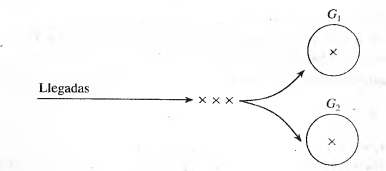


Suponga que queremos simular el modelo anterior manteniendo un registro de las cantidades de tiempo que pasa cada cliente dentro de sistema y el número de servicios realizados por cada servidor. Como hay varios servidores, los clientes no saldrán en el orden de llegada. Por lo tanto, para saber qué cliente deja el sistema al concluir su servicio, necesitamos llevar un registro para ver que clientes están en el sistema. Así, los numeraremos conforme vayan llegando, de modo que el primero en llegar es el cliente numero 1, el siguiente es el numero , y así sucesivamente. Utilizaremos las siguientes variables:

**Variable de tiempo t**

**Variable de estado del sistema (ES)**

$(n, i_1, i_2,..., i_n)$ si hay n clientes en el sistema, $i_1$ está en ell servidor 1, $i_2$ esta con el servidor 2, $i_3$ es el primero de la fila, $i_4$ es el siguiente, y así sucesivamente.

$ES = (0)$ cuando el sistema está vacío y $ES = (1, j, 0)$ o $(1, 0, j)$ cuando el único cliente es j y esté es atendido por el servidor 1 o el 2, respectivamente.

**Variables de conteo**

$N_A$: el número de llegadas hasta en instante t

$C_j$: el npumero de clientes atendidos por, $j=1, 2$ hasta el instante $t$

**Variables de salida**

$A(n)$: la hora de llegada del cliente n, $n\geq1$

$D(n)$: la hora de salida del cliente n, $n\geq1$

**Lista de eventos $t_A, t_1, t_2$**

Donde $t_A$ es la hpra de la siguiente llegada t $t_1$ es la hora en la que concluye el servicio del cliente que en ese momento está siendo atendido por el servidor i, $i=1,2$. Si no hay un cliente actualmente con el servidor i, enotnces hacemos $t_i= ∞$, $i = 1,2$. En lo sucesivo, la lista de eventos siempre constará de las tres variables $t_A, t_1, t_2$.


Para actualizar el sistema nos movemos en el tiempo hasta encontrar el siguiente evento. En los siguientes casos, $Y_i$ siempre se refiere a una variable aleatoria con distribución $G_i$, $i=1, 2$.

In [82]:
from random import expovariate

**PARÁMETROS**

In [83]:
lam = float(input("λ (tasa de llegadas): "))

mu1 = float(input("μ1 (tasa de servicio servidor 1): "))

mu2 = float(input("μ2 (tasa de servicio servidor 2): "))

T = float(input("Tiempo total de simulación: "))

# DISTRIBUCIONES

def TD(): #Tiempo entre llegadas.
    return expovariate(lam)

def Y1():  #Distribución G1.

    return expovariate(mu1)

def Y2(): #Distribución G2.

    return expovariate(mu2)


λ (tasa de llegadas): 4
μ1 (tasa de servicio servidor 1): 5
μ2 (tasa de servicio servidor 2): 6
Tiempo total de simulación: 100


**Inicialización**

$t= N_a = C_1 = C_2 = 0$

$ES = 0$

Generar $t_0$ y hacer $t_A = t_0$, $t_1= t=2=∞$.


In [84]:
t = 0.0

NA = 0          # número de llegadas
ND = 0          # número de salidas

# Estado del sistema
# ES[0] = cliente en servidor 1
# ES[1] = cliente en servidor 2
# ES[2:] = cola

ES = [0, 0]

# Variables de salida

A = {}
D = {}

# Lista de eventos

tA = TD()
t1 = Infinity
t2 = Infinity

**Caso 1**

$ES = ( n, i:1, i_2,...,i_n)$ y $t_A=min(t_A,t_1,t_2)$

Restablecer: $t=t_A$.

Restablecer: $N_A=N_A + 1$

Generar $T_t$ y hacer $t_A=T_t$

Reunir los datos de salida $A(N_A)= t$

Si $ES=(0)$:

Rstablecer $ES=(1,N_A, 0)$

Generar $Y_1$ y hacer $t_1=t+Y_1$

Si $ES=(1, j, 0)$:

Rstablecer $ES=(2, j, N_A)$

Generar $Y_2$ y hacer $t_2=t+Y_2$

Si $ES=(1, 0, j)$:

Rstablecer $ES=(2, N_A,j)$

Generar $Y_1$ y hacer $t_1=t+Y_1$

Si $n > 1$

Restablecer $ES =(n+1, i_1,...,i_n, N_A)$

**Caso 2**

$ES = ( n, i:_1,i_2,...,i_n)$ y $t_1 < t_A \leq t_2$

Restablecer $t=t_1$

Restablecer $C_1=C_1+1$

Reunir los datos de salida $D(i_1)=t$

Si $n_1=1$

Restablecer $ES=(0)$

Restablecer $t_1=\infty$

Si $n_1=2$

Restablecer $ES=(1,0,i_2)$

Restablecer $t_1=\infty$


**Caso 3**


$ES=(n, i_1, i_2,...,i_n)$ y $t_1 < t_A$, $t_2 < t_1$

Restablecer $t=t_2$

Restablecer $C_2=C_2+1$

Reunir datos de salida $D(i_2)=t$

Si $n=1$

$ES=(0)$

$t_1, t_2=\infty$

Si $n=2$

$ES=(1,i_1,0)$

$t_2=\infty$

Si $n> 2$

$ES=(n-1, i_1, i_3,...,i_n)$

Generar $Y_2$ y hacer $t_2=t+Y_2$

In [85]:
# SIMULACIÓN
while True:
    siguiente_llegada = tA if tA <= T else Infinity
    if siguiente_llegada == Infinity and t1 == Infinity and t2 == Infinity:
        break

    # CASO 1

    if siguiente_llegada <= t1 and siguiente_llegada <= t2:
        t = siguiente_llegada
        NA = NA + 1
        A[NA] = t
        # Programar siguiente llegada
        tA = t + TD()

        # Servidor 1 libre

        if ES[0] == 0:
            ES[0] = NA
            t1 = t + Y1()

        # Servidor 2 libre

        elif ES[1] == 0:
            ES[1] = NA
            t2 = t + Y2()

        # Ambos ocupados
        else:
            ES.append(NA)

    # CASO 2

    elif t1 <= siguiente_llegada and t1 <= t2:
        t = t1
        ND = ND + 1
        cliente = ES[0]
        D[cliente] = t

        # Hay cola

        if len(ES) > 2:
            ES[0] = ES[2]
            del ES[2]
            t1 = t + Y1()
        # No hay cola
        else:
            ES[0] = 0
            t1 = Infinity

    # CASO 3

    else:
        t = t2
        ND = ND + 1
        cliente = ES[1]
        D[cliente] = t
        # Hay cola

        if len(ES) > 2:
            ES[1] = ES[2]
            del ES[2]
            t2 = t + Y2()
        # No hay cola
        else:
            ES[1] = 0
            t2 = Infinity


**RESULTADOS**

In [86]:
print("\nRESULTADOS")

print("Llegadas =", NA)

print("Salidas =", ND)

print("Servidor 1 =", ES[0])

print("Servidor 2 =", ES[1])

print("Clientes en cola =", len(ES) - 2)

print("Clientes en sistema =", len([x for x in ES if x != 0]))

if ND > 0:

    W = sum(D[i] - A[i] for i in D) / ND

    print("Tiempo promedio en sistema =", W)

print("\nPrimeras llegadas")

for k in list(A.keys())[:5]:
    print(f"A({k}) = {A[k]:.4f}")

print("\nPrimeras salidas")

for k in list(D.keys())[:5]:
    print(f"D({k}) = {D[k]:.4f}")


RESULTADOS
Llegadas = 400
Salidas = 400
Servidor 1 = 0
Servidor 2 = 0
Clientes en cola = 0
Clientes en sistema = 0
Tiempo promedio en sistema = 0.20117384417915513

Primeras llegadas
A(1) = 0.0734
A(2) = 0.8356
A(3) = 0.8731
A(4) = 1.1238
A(5) = 1.3690

Primeras salidas
D(1) = 0.1323
D(2) = 0.8602
D(4) = 1.1641
D(5) = 1.6571
D(6) = 1.8393


#**Variables antitéticas para la estimación de $\int_0^1 e^{x^2}\,dx$**

Las técnicas de reducción de varianza permiten mejorar la precisión de un estimador sin incrementar significativamente el número de simulaciones realizadas.

Recordemos que para dos variables aleatorias $X_1$ y $X_2$,

$$
\operatorname{Var}\left(\frac{X_1+X_2}{2}\right)
=
\frac{1}{4}
\left[
\operatorname{Var}(X_1)
+
\operatorname{Var}(X_2)
+
2\operatorname{Cov}(X_1,X_2)
\right].
$$

donde

$$
\operatorname{Cov}(X_1,X_2)
=
E[X_1X_2]
-
E[X_1]E[X_2].
$$

Para aplicar el método de variables antitéticas se construyen dos estimadores insesgados de

$$
\theta
=
\int_0^1 e^{x^2}\,dx.
$$

Definimos

$$
f(x)=e^{x^2}.
$$

Entonces,

$$
X_1
=
\frac{1}{N}
\sum_{i=1}^{N}
f(U_i),
\qquad
U_i\sim U(0,1),
$$

y

$$
X_2
=
\frac{1}{N}
\sum_{i=1}^{N}
f(1-U_i).
$$

El estimador con variables antitéticas es

$$
\hat{\theta}_{AV}
=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{
f(U_i)+f(1-U_i)
}{2}.
$$

Sustituyendo la función de interés,

$$
\hat{\theta}_{AV}
=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{
e^{U_i^2}
+
e^{(1-U_i)^2}
}{2}.
$$

Debido a que $e^{x^2}$ es una función creciente en $[0,1]$, los términos $e^{U_i^2}$ y $e^{(1-U_i)^2}$ tienden a presentar correlación negativa. Como consecuencia, la covarianza disminuye la varianza del estimador, produciendo una estimación más precisa que el método Monte Carlo crudo.

In [87]:
import numpy as np

In [88]:
def montecarlo_antitetico(d, n=100):
    media = 0
    S = 0
    j = 0
    while True:
        u = np.random.uniform(0, 1)
        x1 = np.exp(u**2)
        x2 = np.exp((1-u)**2)
        x = (x1 + x2)/2
        j += 1

        if j == 1:
            media = x
            S = 0

        else:
            media_anterior = media

            media = media_anterior + (x - media_anterior)/j

            S = ((1 - 1/j)*S
                 + (j + 1)*(media - media_anterior)**2)

        if j >= n and j > 1:

            error = np.sqrt(S/j)

            if error < d:
                break

    return media, error, np.sqrt(S), j

**RESULTADOS**

In [89]:
media1, error1, desv1, n1 = montecarlo_antitetico(0.01)

media2, error2, desv2, n2 = montecarlo_antitetico(0.001)

print("d = 0.01")
print(media1, error1, n1)

print("\nd = 0.001")
print(media2, error2, n2)

d = 0.01
1.4720442200246875 0.009993709992059 301

d = 0.001
1.4626667583299142 0.0009999890838161948 28046


# **Bootstrap**

Suponga que $X_1,...,X_n$ son variables aleatorias independientes con una función de distribución común F. Queremos estimar $\theta(F)$ mediante el estimador $g(X_1,...,X_n)$. Entonces

$E(M(F))= E_F[ (g(X_1,...,X_n)-\theta(F))^2]$

Estimaremos F con

$F_e(x) = \frac{\text{numero de i: X_i }\leq  x}{n}$

Distribución empírica.

**Ejemplo** Esta es una muestra aleatoria de 12 tiempos de entrega:

35, 42, 38, 40 ,45, 37, 39, 41, 44, 36, 43, 40

Instrucciones:


1.   Usa la muestra original de 12 observaciones y genere 1000 muestras bootstrap
2.   Para cada muestra B calcule la media
3.   Al final:

*   Obtenga la media de las 1000 muestras
*   Calcule la desviación estandar
*   Determine los percentiles  25% y 97.5% para construir el intervalo de confianza B del 95%


In [90]:
import random
import numpy as np

# Muestra original
datos = [35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40]

B = 1000   # número de muestras bootstrap
n = len(datos)

# Fijar semilla para que el resultado sea reproducible
random.seed(12345)

In [91]:
def media(lista):
    return sum(lista) / len(lista)

def muestra_bootstrap(datos):
    n = len(datos)
    resample = []
    for _ in range(n):
        resample.append(datos[random.randrange(n)])
    return resample

In [92]:
# Generar las 1000 medias bootstrap
medias_bootstrap = []

for _ in range(B):
    mues = muestra_bootstrap(datos)
    medias_bootstrap.append(media(mues))

In [93]:
# Resultados finales
media_boot = np.mean(medias_bootstrap)

# Desviación estándar muestral
desv_boot = np.std(medias_bootstrap, ddof=1)

# Percentiles para el IC bootstrap del 95%
p25, p975 = np.percentile(medias_bootstrap, [25, 97.5])

print("Media bootstrap de las 1000 muestras:", media_boot)
print("Desviación estándar:", desv_boot)
print("Percentil 25%:", p25)
print("Percentil 97.5%:", p975)
print("Intervalo de confianza bootstrap 95%: [", p25, ",", p975, "]")

Media bootstrap de las 1000 muestras: 39.9735
Desviación estándar: 0.8850128046141467
Percentil 25%: 39.333333333333336
Percentil 97.5%: 41.58541666666667
Intervalo de confianza bootstrap 95%: [ 39.333333333333336 , 41.58541666666667 ]


#**JACKKNIFE**

Tenemos una muestra de n datos. En esta técnica eliminamos uno de los datos para obtener n muestras de tamaño n-1.

Para cada muestra calculamos el estadistico $\hat{\theta}_i$ y luego obtenemos el promedio del darkknife

$\theta = \frac{1}{n} \sum_{i=1}^n \hat{\theta}_i$

y la varianza

$\operatorname{Var}_{jack}= \frac{n-1}{n}\sum_{i=1}^n(\theta - \hat{\theta}_i)^2$

**Ejercicio**

Programar usando la muestra del ejercicio del Bootstrap

{35, 42, 38, 40 ,45, 37, 39, 41, 44, 36, 43, 40}

In [94]:
n = len(datos) #tomar tamaño de la muestra de datos de Bootstrap

**Construir las n muestras jackknife de tamaño n-1**

In [95]:
theta_i = []   # estadísticos

for i in range(n):
    muestra_jack = datos[:i] + datos[i+1:]   # elimina el dato i
    theta_i.append(media(muestra_jack))

**Resultados**

In [96]:
# 2) Promedio jackknife
theta_jack = media(theta_i)

# 3) Varianza jackknife
var_jack = (n - 1) / n * sum((theta_jack - x) ** 2 for x in theta_i)

print("\nPromedio jackknife:", theta_jack)
print("Varianza jackknife:", var_jack)
print("Desviación estándar jackknife:", var_jack ** 0.5)


Promedio jackknife: 40.0
Varianza jackknife: 0.8333333333333356
Desviación estándar jackknife: 0.9128709291752781
